In [2]:
from __future__ import annotations
from helpers.env import ACTIONS
from helpers.viz import evaluate, plot_policy, plot_value_heatmap, run_to_gif
from helpers.viz import greedy_policy_from_V
import numpy as np
import matplotlib.pyplot as plt
from ModifiedSlipperyGridWorld import ModifiedSlipperyGridWorld

In [3]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)

(0, 1, 2, 3)


In [4]:
# =============================CONFIGURATION BLOCK============================= #
# |                   Change the parameters and see what happens              | #
# =============================CONFIGURATION BLOCK============================= #

num_rows = 5
num_cols = 7
start_state = (0, 0)
goal_state = (4, 6)
slip_prob = 0.2
random_seed = 987
step_reward = -1
goal_reward = 10

# VI parameters
max_number_iterations = 100 # max number of value iterations
threshold = 1e-5 # stopping condition
gamma = 0.99 # discount factor
alpha = 0.15

# Evaluation parameters
max_steps_in_env = 200 # used for episodic evaluation


In [16]:
obstacles = [(0, 2), (2, 0)]
traps = [(3, 3)]

env = ModifiedSlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed,
                                obstacles=obstacles,  traps=traps, trap_reward=-20)

s = env.reset()

num_states = num_rows * num_cols
V = np.zeros(num_states)

for i in range(max_number_iterations):
    V_i = V.copy()
    d = 0
    for s in range(num_states):
        if (env.is_terminal_state(s)):
            continue
        R = []
        for a in ACTIONS:
            val = 0
            for p, sn in env.get_transition_distribution(s, a):
                r = env.reward(s, a, sn)
                val += p * (r + gamma * V[sn])
            R.append(val)
        V_i[s] = max(R)
        d = max(d, abs(V_i[s] - V[s]))

    V = V_i
    if d < threshold:
        print(f"Iterations count: {i}")
        break

Iterations count: 35


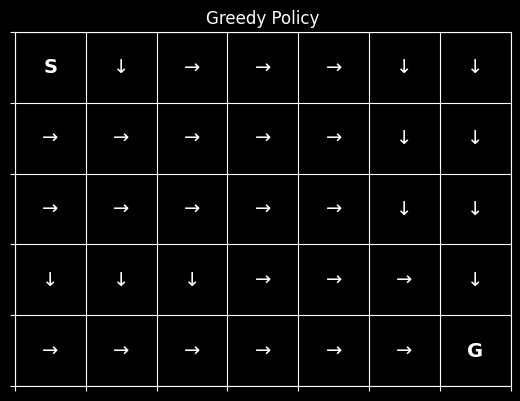

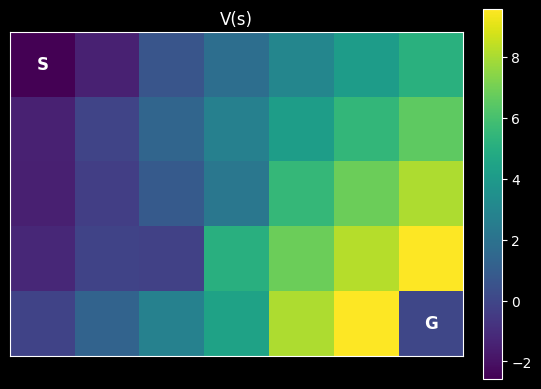

{'avg_return': -1.38, 'std_return': 2.1156, 'success_rate': 1.0, 'avg_steps': 12.38}


In [17]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

env.reset()

pi = greedy_policy_from_V(V, env, gamma)

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy")
plot_value_heatmap(env, V, filename=value_plot_name, title="V(s)")
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

In [19]:
import random

In [20]:
s = env.reset()

num_states = num_rows * num_cols
num_actions = 4
num_elems = (num_states, num_actions)

Q = np.zeros(num_elems)

epsilon = 0.1

def eps_greedy(state):
    if random.random() < epsilon:
        return random.randint(0, 3)
    return np.argmax(Q[state])


for i in range(5000):
    X = random.randint(0, num_states - 2)
    X = env.reset()
    while not env.is_terminal_state(X):
        A = eps_greedy(X)
        X_prim, R, _, _ = env.step(A)
        Q[X][A] = Q[X][A] + alpha * (R + gamma * np.max(Q[X_prim]) - Q[X][A])
        X = X_prim

def get_states(state):
    return np.max(Q[state])

def greedy_policy(state):
    return int(np.argmax(Q[state]))

V = np.zeros(num_states)
for i in range(num_states):
    V[i] = get_states(i)

pi = np.zeros(num_states)
for i in range(num_states):
    pi[i] = greedy_policy(i)


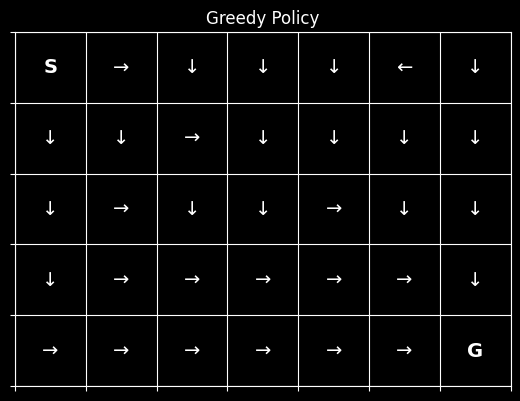

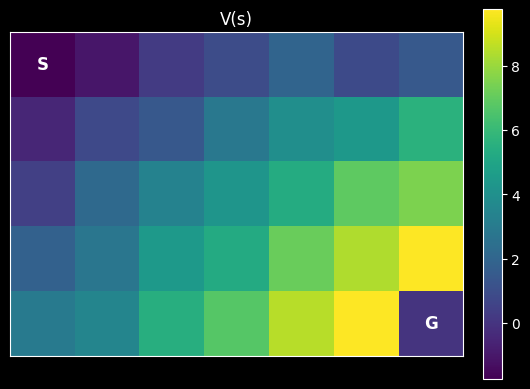

{'avg_return': -1.5, 'std_return': 2.2113, 'success_rate': 1.0, 'avg_steps': 12.5}


In [21]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

env.reset()

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy")
plot_value_heatmap(env, V, filename=value_plot_name, title="V(s)")
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

In [22]:
s = env.reset()

num_states = num_rows * num_cols
num_actions = 4
num_elems = (num_states, num_actions)

Q = np.zeros(num_elems)

epsilon = 0.1

def eps_greedy(state):
    if random.random() < epsilon:
        return random.randint(0, 3)
    return np.argmax(Q[state])


for i in range(5000):
    X = env.reset()
    A = eps_greedy(X)
    while not env.is_terminal_state(X):
        X_prim, R, done, _ = env.step(A)
        if done:
            Q[X][A] = alpha * (R - Q[X][A])
            break
        A_prim = eps_greedy(X_prim)
        Q[X][A] = Q[X][A] + alpha * (R + gamma * Q[X_prim][A_prim] - Q[X][A])
        X = X_prim
        A = A_prim


def get_states(state):
    return np.max(Q[state])

def get_policy(state):
    return int(np.argmax(Q[state]))

V = np.zeros(num_states)
for i in range(num_states):
    V[i] = get_states(i)

pi = np.zeros(num_states)
for i in range(num_states):
    pi[i] = get_policy(i)

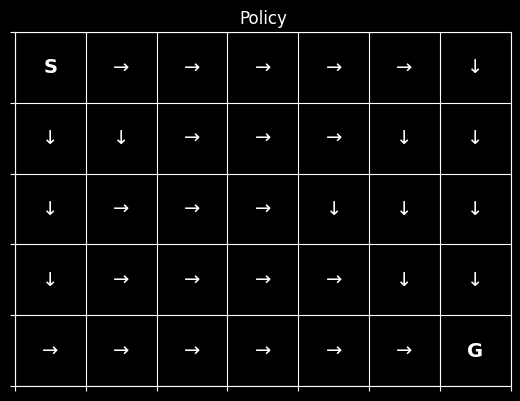

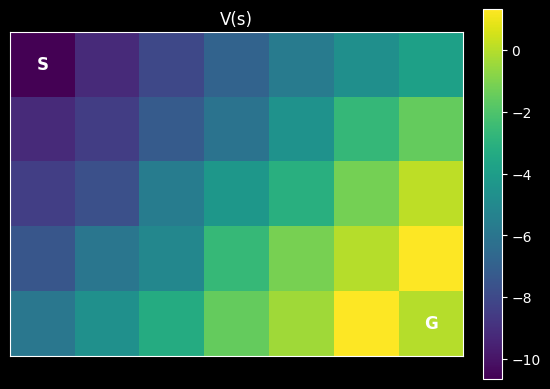

{'avg_return': -1.34, 'std_return': 2.1224, 'success_rate': 1.0, 'avg_steps': 12.34}


In [23]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

env.reset()

plot_policy(env, pi, filename=policy_plot_name, title="Policy")
plot_value_heatmap(env, V, filename=value_plot_name, title="V(s)")
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

In [28]:
s = env.reset()

num_states = num_rows * num_cols
num_actions = 4
num_elems = (num_states, num_actions)

Q = np.zeros(num_elems)

epsilon = 0.1
n = 5
model = {}

def eps_greedy(state):
    if random.random() < epsilon:
        return random.randint(0, 3)
    return np.argmax(Q[state])


for i in range(5000):
    X = random.randint(0, num_states - 2)
    X = env.reset()

    while not env.is_terminal_state(X):
        A = eps_greedy(X)
        X_prim, R, _, _ = env.step(A)
        Q[X][A] = Q[X][A] + alpha * (R + gamma * np.max(Q[X_prim]) - Q[X][A])
        X = X_prim

        model[(X, A)] = (R, X_prim)

        for j in range(n):
            prev_X, prev_A = random.choice(list(model.keys()))
            prev_R, prev_X_prim = model[(prev_X, prev_A)]
            Q[prevX][prevA] = Q[prevX][prevA] + alpha * (R + gamma * np.max(Q[prevX_prim]) - Q[prevX][prevA])

def get_states(state):
    return np.max(Q[state])

def greedy_policy(state):
    return int(np.argmax(Q[state]))

V = np.zeros(num_states)
for i in range(num_states):
    V[i] = get_states(i)

pi = np.zeros(num_states)
for i in range(num_states):
    pi[i] = greedy_policy(i)


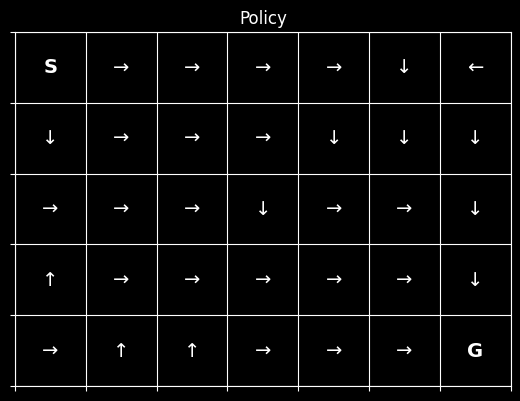

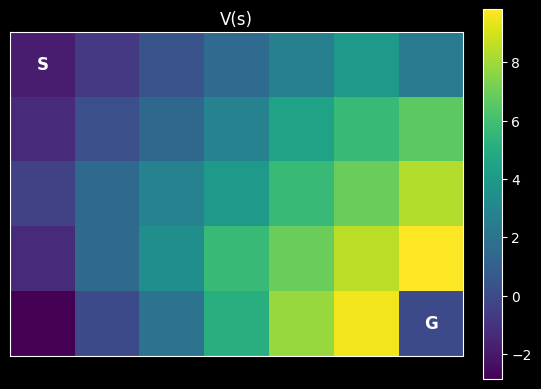

{'avg_return': -1.1, 'std_return': 2.0025, 'success_rate': 1.0, 'avg_steps': 12.1}


In [29]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

env.reset()

plot_policy(env, pi, filename=policy_plot_name, title="Policy")
plot_value_heatmap(env, V, filename=value_plot_name, title="V(s)")
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)